In [3]:
#Ahmed Ali Alyousif/2230004696/8MA2.
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data   # provides sample images (camera, checkerboard, coins, ...)

# Make plots show inside the notebook
%matplotlib inline

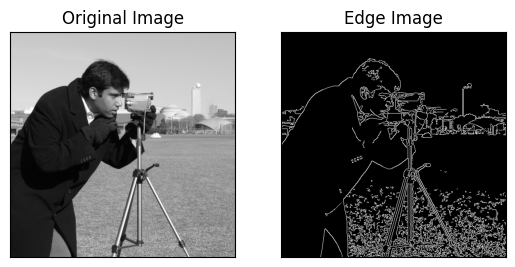

In [12]:
# --- Code from the lab manual ---
img = data.camera()                                  

edges = cv2.Canny(img, 100, 200)

plt.subplot(121), plt.imshow(img, cmap='gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(edges, cmap='gray')
plt.title('Edge Image'), plt.xticks([]), plt.yticks([])
plt.show()

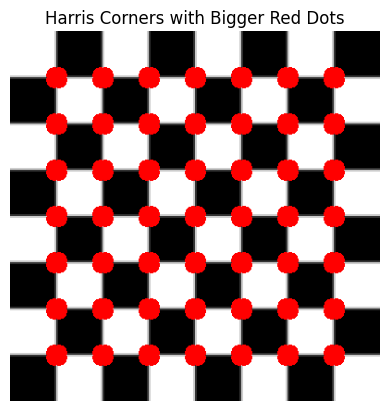

In [17]:
# --- Code from the lab manual ---
board = data.checkerboard()                        
image = cv2.cvtColor(board, cv2.COLOR_GRAY2BGR)
image = cv2.resize(image, (400, 400), interpolation=cv2.INTER_NEAREST)

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
gray = np.float32(gray)

# Harris Corner Detection
harris = cv2.cornerHarris(gray, blockSize=2, ksize=3, k=0.04)
harris = cv2.dilate(harris, None)   # to mark corners more clearly

# Threshold for detecting strong corners
threshold = 0.01 * harris.max()
corner_coords = np.argwhere(harris > threshold)

# Draw larger red dots (radius = 7)
for y, x in corner_coords:
    cv2.circle(image, (x, y), radius=7, color=(0, 0, 255), thickness=-1)  # -1 = filled

# Display
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Harris Corners with Bigger Red Dots')
plt.axis('off')
plt.show()

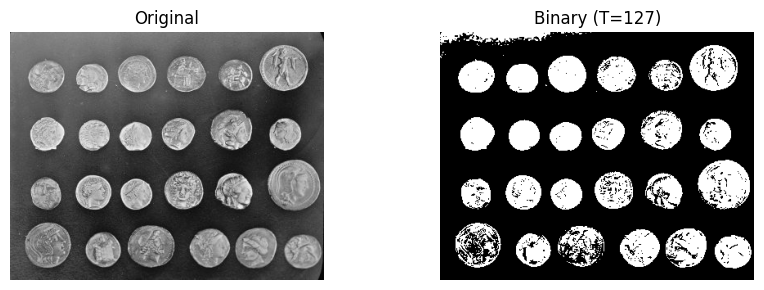

(None, None)

In [6]:
img = data.coins()

T = 127
_, binary = cv2.threshold(img, T, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(9, 3))
plt.subplot(1, 2, 1), plt.imshow(img, cmap='gray'), plt.title('Original'), plt.axis('off')
plt.subplot(1, 2, 2), plt.imshow(binary, cmap='gray'), plt.title(f'Binary (T={T})'), plt.axis('off')
plt.tight_layout(), plt.show()

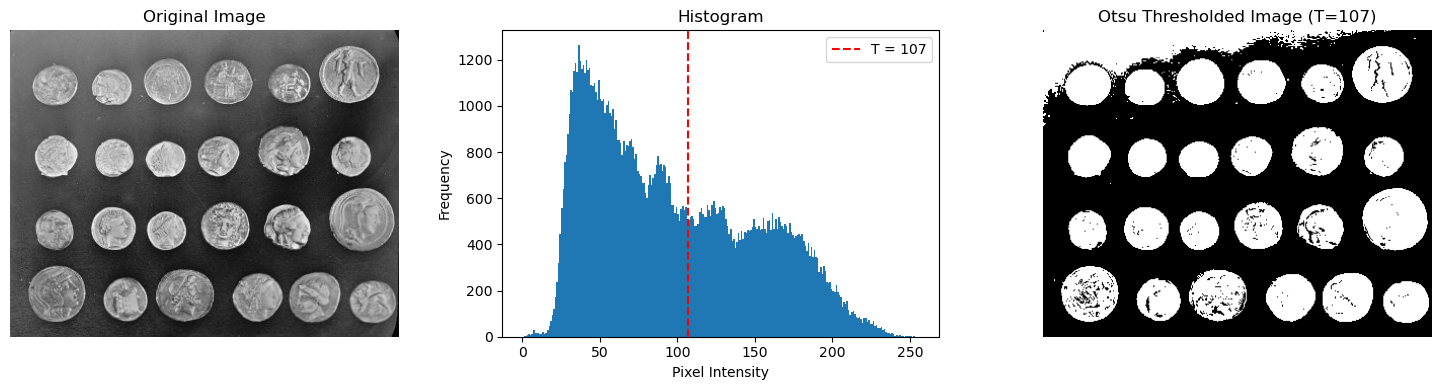

In [2]:

# --- Q1 Solution: Otsu's Thresholding ---

img = data.coins()

# Apply Otsu's thresholding
T, otsu = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Plot original image
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

# Plot histogram
plt.subplot(1, 3, 2)
plt.hist(img.ravel(), bins=256, range=(0, 256))
plt.axvline(T, color='r', linestyle='--', label=f'T = {T:.0f}')
plt.title('Histogram')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.legend()

# Plot thresholded image
plt.subplot(1, 3, 3)
plt.imshow(otsu, cmap='gray')
plt.title(f"Otsu Thresholded Image (T={T:.0f})")
plt.axis('off')

plt.tight_layout()
plt.show()
